# Email Security & Phishing Detection (Google Colab Upload Version)

**Section 1 of the ML in Cyber Security assignment (25 marks)**

This is a Colab-friendly variant of `phishing_detection.ipynb`: instead of downloading the dataset from Kaggle via `kagglehub`, you upload the CSV yourself directly in Google Colab. Use this version if you don't have Kaggle API credentials configured, or just prefer to upload the file manually.

This notebook builds and compares two models for detecting phishing/malicious emails from their text content:

1. **Classic Machine Learning:** TF-IDF features + Logistic Regression
2. **Deep Learning:** Tokenized sequences + an LSTM neural network

**Dataset:** [Enron Spam Data](https://www.kaggle.com/datasets/marcelwiechmann/enron-spam-data) (Kaggle). The dataset's `spam` / `ham` labels are used as a proxy for `phishing` / `legitimate`, consistent with the assignment brief's own suggested dataset list (Enron Spam, SpamAssassin, UCI Phishing). This is a documented limitation discussed at the end of the notebook: not every spam email is a phishing email, but the two problems share the same text-classification setup, and spam corpora are the standard stand-in used in coursework and much of the phishing-detection literature.

**Before running:** download the dataset CSV from Kaggle to your computer. You do **not** need to upload it into Colab yourself first — the data-loading cell below will open Colab's upload dialog automatically if it can't find the file. (If you'd rather upload it ahead of time via the Files sidebar, that works too — see the "Load Dataset" section below for exactly where to put it.)

In [1]:
import os

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Running in Google Colab:", IN_COLAB)
print("Working directory:", os.getcwd())

Running in Google Colab: True
Working directory: /content


In [2]:
import os
import re
import glob
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc,
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import joblib

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Separate output folder from the Kaggle-download notebook so running both
# side by side doesn't overwrite each other's figures/models.
OUTPUT_DIR = "outputs_local"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
MODELS_DIR = os.path.join(OUTPUT_DIR, "models")
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("punkt", quiet=True)

print("Setup complete.")

Setup complete.


## 1. Load Dataset (Google Colab Upload)

This notebook does **not** download anything itself. It looks for `enron_spam_data.csv` in the most common places a file ends up after uploading it in Colab:

- `data/enron_spam_data.csv` (if you created a `data` folder in the Files sidebar and uploaded into it)
- `enron_spam_data.csv` directly in `/content` (the default location if you just drag-and-drop the file into the Files sidebar root, or use the folder icon's "Upload" button without creating a subfolder)

**If it can't find the file anywhere, the cell below will automatically open Colab's upload dialog** so you can pick the CSV from your computer — no need to fix folders/paths yourself. Uploaded files land in `/content`, which this cell also checks.

Note: anything uploaded this way only lives for the current Colab session/runtime — if the runtime restarts or disconnects, you'll need to upload again.

In [3]:
EXPECTED_FILENAME = "enron_spam_data.csv"
CANDIDATE_DIRS = ["data", ".", "/content", "/content/data"]


def find_dataset_path():
    checked_dirs = []
    for directory in CANDIDATE_DIRS:
        if directory in checked_dirs:
            continue
        checked_dirs.append(directory)
        exact_path = os.path.join(directory, EXPECTED_FILENAME)
        if os.path.exists(exact_path):
            return exact_path

    for directory in checked_dirs:
        if os.path.isdir(directory):
            csv_files = sorted(glob.glob(os.path.join(directory, "*.csv")))
            if len(csv_files) == 1:
                return csv_files[0]

    return None


def load_local_dataset():
    dataset_path = find_dataset_path()

    if dataset_path is None and IN_COLAB:
        print(
            f"Could not find '{EXPECTED_FILENAME}' in {CANDIDATE_DIRS}. "
            "Opening the upload dialog -- please choose the CSV file from your computer..."
        )
        from google.colab import files
        files.upload()  # uploaded file(s) are saved into the current working directory
        dataset_path = find_dataset_path()

    if dataset_path is None:
        raise FileNotFoundError(
            f"Could not find the dataset. Expected '{EXPECTED_FILENAME}' in one of: {CANDIDATE_DIRS}.\n"
            "In Google Colab: re-run this cell to trigger the upload dialog, or manually upload the "
            "CSV via the Files sidebar (into '/content' or a 'data' subfolder), then re-run this cell.\n"
            "See README.md for details."
        )

    print(f"Loading dataset from '{dataset_path}' ...")
    return pd.read_csv(dataset_path)


df = load_local_dataset()
print("Shape:", df.shape)
df.head()

Could not find 'enron_spam_data.csv' in ['data', '.', '/content', '/content/data']. Opening the upload dialog -- please choose the CSV file from your computer...


Saving enron_spam_data.csv to enron_spam_data.csv
Loading dataset from './enron_spam_data.csv' ...
Shape: (33716, 5)


,Unnamed: 0,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14


## 2. Column Detection & Label Normalization

The exact column names in the CSV you place in `data/` can vary depending on where it came from, so the cell below auto-detects the email-text column and the label column by keyword matching, then normalizes labels to `0` (legitimate/ham) and `1` (phishing/spam).

If auto-detection picks the wrong columns for your file, override `TEXT_COL` / `LABEL_COL` manually using the commented-out lines, after checking `df.columns` above.

In [4]:
def detect_column(columns, keywords):
    lowered = {c: str(c).lower() for c in columns}
    for keyword in keywords:
        for col, low in lowered.items():
            if keyword in low:
                return col
    return None


TEXT_COL = detect_column(df.columns, ["message", "text", "body", "content", "email"])
LABEL_COL = detect_column(df.columns, ["label", "class", "spam/ham", "spam", "ham", "target"])

# Override manually here if auto-detection picks the wrong column, e.g.:
# TEXT_COL = "Message"
# LABEL_COL = "Spam/Ham"

assert TEXT_COL is not None, f"Could not auto-detect a text column among {list(df.columns)}. Set TEXT_COL manually."
assert LABEL_COL is not None, f"Could not auto-detect a label column among {list(df.columns)}. Set LABEL_COL manually."

print(f"Using text column:  '{TEXT_COL}'")
print(f"Using label column: '{LABEL_COL}'")

df = df[[TEXT_COL, LABEL_COL]].dropna().rename(columns={TEXT_COL: "text", LABEL_COL: "label_raw"})


def normalize_label(value):
    if isinstance(value, (int, np.integer, float, np.floating)):
        return int(value)
    text_value = str(value).strip().lower()
    if text_value in ("spam", "phishing", "1", "malicious", "bad"):
        return 1
    if text_value in ("ham", "legitimate", "0", "safe", "good"):
        return 0
    raise ValueError(f"Unrecognized label value: {value!r}")


df["label"] = df["label_raw"].apply(normalize_label)
df = df.drop(columns=["label_raw"]).reset_index(drop=True)

print("\nLabel distribution (0 = legitimate, 1 = phishing/spam):")
print(df["label"].value_counts())

Using text column:  'Message'
Using label column: 'Spam/Ham'

Label distribution (0 = legitimate, 1 = phishing/spam):
label
1    17171
0    16493
Name: count, dtype: int64


## 3. Exploratory Data Analysis

A quick look at class balance, email length, and a couple of raw samples before any cleaning.

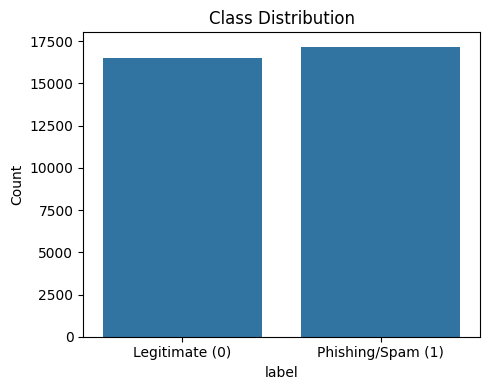

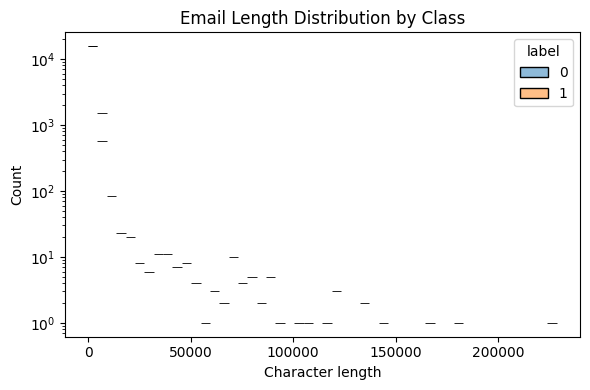

Sample legitimate email:
 gary , production from the high island larger block a - 1 # 2 commenced on
saturday at 2 : 00 p . m . at about 6 , 500 gross . carlos expects between 9 , 500 and
10 , 000 gross for tomorrow . vastar owns 68 % of the gross production .
george x 3 - 6992
- - - - - - - - - - - - - - - - - - - - - - forwarded by george weissman / hou / ect on 12 / 13 / 99 10 : 16
am - - - - - - - - - - - - - - - - - - - - - - - - - - -
daren j farmer
12 / 10 / 99 10 : 38 am
to : carlos j rodriguez / hou / ect @ ect


Sample phishing/spam email:
 i tried calling you this am but your phone rolled to someone else ' s voicemail . can you call me when you get a chance ?
- - - - - original message - - - - -
from : farmer , daren j .
sent : thursday , january 10 , 2002 2 : 06 pm
to : hill , garrick
subject : re : tenaska iv
rick ,
i ' ve had a couple of meetings today . i ' m sorry i ' m just getting back to you . i tried to call but the voice mail said that you were unavailable . so , g

In [5]:
plt.figure(figsize=(5, 4))
sns.countplot(x="label", data=df)
plt.xticks([0, 1], ["Legitimate (0)", "Phishing/Spam (1)"])
plt.title("Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "class_distribution.png"), dpi=150)
plt.show()

df["text_length"] = df["text"].astype(str).apply(len)

plt.figure(figsize=(6, 4))
sns.histplot(data=df, x="text_length", hue="label", bins=50, log_scale=(False, True))
plt.title("Email Length Distribution by Class")
plt.xlabel("Character length")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "text_length_distribution.png"), dpi=150)
plt.show()

print("Sample legitimate email:\n", df[df.label == 0]["text"].iloc[0][:500])
print("\nSample phishing/spam email:\n", df[df.label == 1]["text"].iloc[0][:500])

## 4. Text Preprocessing

Each email is cleaned with the following steps before being fed to either model:

1. Lowercase the text.
2. Strip URLs and HTML tags.
3. Remove punctuation/digits, keeping only alphabetic tokens.
4. Remove English stopwords.
5. Lemmatize remaining tokens (reduce to dictionary root form) and drop very short tokens (length &le; 2).

The result is stored in a new `clean_text` column, which both the TF-IDF/Logistic Regression model and the LSTM's tokenizer are built on.

In [6]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

URL_RE = re.compile(r"https?://\S+|www\.\S+")
HTML_RE = re.compile(r"<.*?>")
NON_ALPHA_RE = re.compile(r"[^a-z\s]")


def clean_text(text):
    text = str(text).lower()
    text = URL_RE.sub(" ", text)
    text = HTML_RE.sub(" ", text)
    text = NON_ALPHA_RE.sub(" ", text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens if tok not in stop_words and len(tok) > 2]
    return " ".join(tokens)


df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.strip().astype(bool)].reset_index(drop=True)

print(f"Rows after cleaning: {len(df)}")
df[["text", "clean_text", "label"]].head()

Rows after cleaning: 33653


,text,clean_text,label
0,"gary , production from the high island larger ...",gary production high island larger block comme...,0
1,- calpine daily gas nomination 1 . doc,calpine daily gas nomination doc,0
2,fyi - see note below - already done .\nstella\...,fyi see note already done stella forwarded ste...,0
3,fyi .\n- - - - - - - - - - - - - - - - - - - -...,fyi forwarded lauri allen hou ect kimberly vau...,0
4,"jackie ,\nsince the inlet to 3 river plant is ...",jackie since inlet river plant shut last day f...,0


## 5. Train / Test Split

An 80/20 stratified split is used so both classes keep the same proportion in train and test sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["label"], test_size=0.2, random_state=SEED, stratify=df["label"]
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 26922, Test size: 6731


## 6. Classic Machine Learning — TF-IDF + Logistic Regression

`TfidfVectorizer` converts each cleaned email into a weighted bag-of-unigram/bigram vector (capped at 10,000 features), which a `LogisticRegression` classifier is trained on.

In [8]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=SEED)
log_reg.fit(X_train_tfidf, y_train)

y_pred_lr = log_reg.predict(X_test_tfidf)
y_proba_lr = log_reg.predict_proba(X_test_tfidf)[:, 1]

print("=== Logistic Regression (TF-IDF) ===")
print(classification_report(y_test, y_pred_lr, target_names=["Legitimate", "Phishing/Spam"]))

=== Logistic Regression (TF-IDF) ===
               precision    recall  f1-score   support

   Legitimate       1.00      1.00      1.00      3297
Phishing/Spam       1.00      1.00      1.00      3434

     accuracy                           1.00      6731
    macro avg       1.00      1.00      1.00      6731
 weighted avg       1.00      1.00      1.00      6731



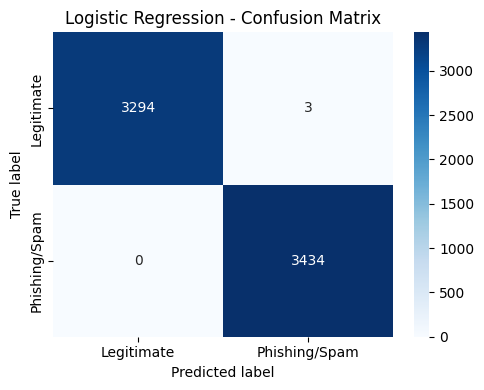

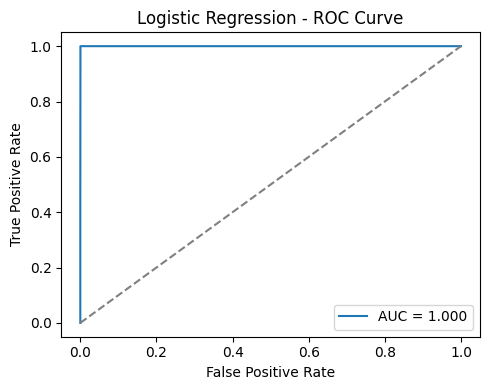

Saved TF-IDF vectorizer and Logistic Regression model to outputs_local/models


In [9]:
def plot_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Legitimate", "Phishing/Spam"],
        yticklabels=["Legitimate", "Phishing/Spam"],
    )
    plt.title(title)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, filename), dpi=150)
    plt.show()


def plot_roc_curve(y_true, y_proba, title, filename):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, filename), dpi=150)
    plt.show()
    return roc_auc


plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression - Confusion Matrix", "lr_confusion_matrix.png")
auc_lr = plot_roc_curve(y_test, y_proba_lr, "Logistic Regression - ROC Curve", "lr_roc_curve.png")

joblib.dump(tfidf, os.path.join(MODELS_DIR, "tfidf_vectorizer.joblib"))
joblib.dump(log_reg, os.path.join(MODELS_DIR, "logistic_regression.joblib"))
print("Saved TF-IDF vectorizer and Logistic Regression model to", MODELS_DIR)

## 7. Deep Learning — LSTM

Text is tokenized into integer sequences (vocabulary capped at 10,000 words), padded/truncated to a fixed length of 200 tokens, and fed into an `Embedding -> LSTM -> Dense` network trained end-to-end for binary classification.

In [10]:
MAX_VOCAB = 10000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

lstm_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid"),
])

lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
lstm_model.summary()

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = lstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1,
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 289s 727ms/step - accuracy: 0.5806 - loss: 0.5945 - val_accuracy: 0.5841 - val_loss: 0.5752
Epoch 2/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 305s 710ms/step - accuracy: 0.5870 - loss: 0.5766 - val_accuracy: 0.5841 - val_loss: 0.5753
Epoch 3/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 323s 711ms/step - accuracy: 0.8879 - loss: 0.1815 - val_accuracy: 0.9981 - val_loss: 0.0123
Epoch 4/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 318s 702ms/step - accuracy: 0.9980 - loss: 0.0131 - val_accuracy: 0.9985 - val_loss: 0.0104
Epoch 5/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 266s 701ms/step - accuracy: 0.9985 - loss: 0.0111 - val_accuracy: 0.9989 - val_loss: 0.0079
Epoch 6/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 268s 708ms/step - accuracy: 0.9980 - loss: 0.0134 - val_accuracy: 0.9989 - val_loss: 0.0079
Epoch 7/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 267s 704ms/step - accuracy: 0.9989 - loss: 0.0089 - val_accuracy: 0.9993 - val_loss: 0.0059
Epoch 8/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 270s 712ms/step - accuracy: 0.9983 -

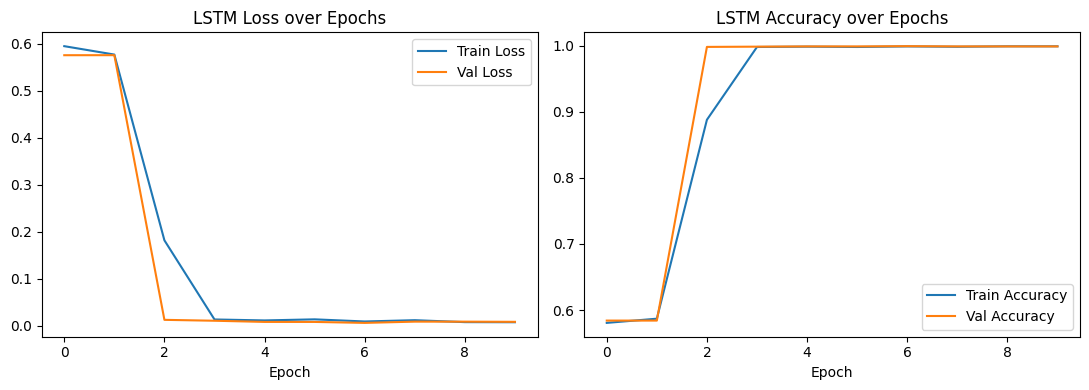

211/211 ━━━━━━━━━━━━━━━━━━━━ 30s 140ms/step
=== LSTM ===
               precision    recall  f1-score   support

   Legitimate       1.00      1.00      1.00      3297
Phishing/Spam       1.00      1.00      1.00      3434

     accuracy                           1.00      6731
    macro avg       1.00      1.00      1.00      6731
 weighted avg       1.00      1.00      1.00      6731



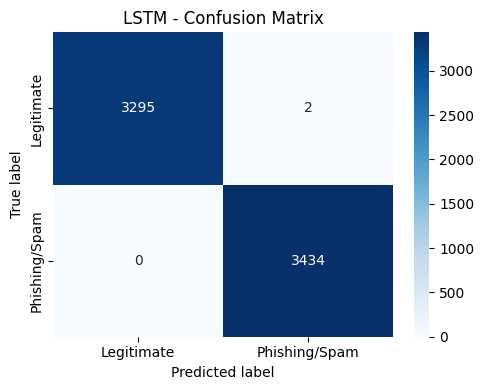

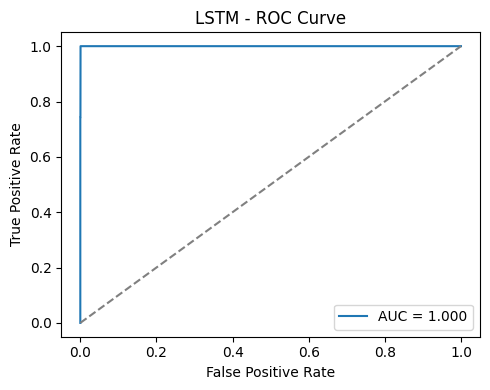

Saved LSTM model and tokenizer config to outputs_local/models


In [11]:
def plot_training_history(history, filename):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(history.history["loss"], label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Val Loss")
    axes[0].set_title("LSTM Loss over Epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history.history["accuracy"], label="Train Accuracy")
    axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
    axes[1].set_title("LSTM Accuracy over Epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, filename), dpi=150)
    plt.show()


plot_training_history(history, "lstm_training_curves.png")

y_proba_lstm = lstm_model.predict(X_test_pad).ravel()
y_pred_lstm = (y_proba_lstm >= 0.5).astype(int)

print("=== LSTM ===")
print(classification_report(y_test, y_pred_lstm, target_names=["Legitimate", "Phishing/Spam"]))

plot_confusion_matrix(y_test, y_pred_lstm, "LSTM - Confusion Matrix", "lstm_confusion_matrix.png")
auc_lstm = plot_roc_curve(y_test, y_proba_lstm, "LSTM - ROC Curve", "lstm_roc_curve.png")

lstm_model.save(os.path.join(MODELS_DIR, "lstm_model.keras"))
with open(os.path.join(MODELS_DIR, "tokenizer_config.json"), "w") as f:
    f.write(tokenizer.to_json())
print("Saved LSTM model and tokenizer config to", MODELS_DIR)

## 8. Model Comparison

Accuracy, precision, recall, F1-score, and ROC-AUC for both models side by side.

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Logistic Regression (TF-IDF),0.999554,0.999127,1.0,0.999563,0.999880
LSTM,0.999703,0.999418,1.0,0.999709,0.999883


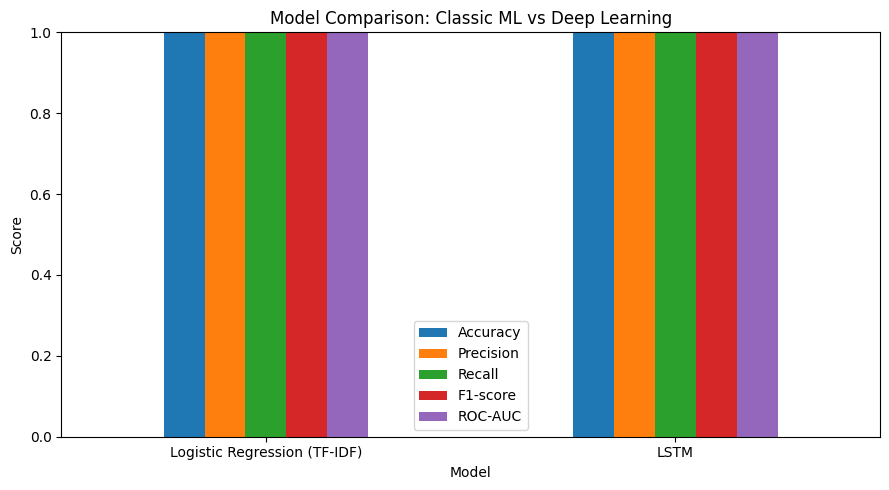

Saved comparison table to outputs_local/model_comparison.csv


In [12]:
results = pd.DataFrame([
    {
        "Model": "Logistic Regression (TF-IDF)",
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "Precision": precision_score(y_test, y_pred_lr),
        "Recall": recall_score(y_test, y_pred_lr),
        "F1-score": f1_score(y_test, y_pred_lr),
        "ROC-AUC": auc_lr,
    },
    {
        "Model": "LSTM",
        "Accuracy": accuracy_score(y_test, y_pred_lstm),
        "Precision": precision_score(y_test, y_pred_lstm),
        "Recall": recall_score(y_test, y_pred_lstm),
        "F1-score": f1_score(y_test, y_pred_lstm),
        "ROC-AUC": auc_lstm,
    },
]).set_index("Model")

display(results)

results.plot(kind="bar", figsize=(9, 5), ylim=(0, 1))
plt.title("Model Comparison: Classic ML vs Deep Learning")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "model_comparison.png"), dpi=150)
plt.show()

results.to_csv(os.path.join(OUTPUT_DIR, "model_comparison.csv"))
print("Saved comparison table to", os.path.join(OUTPUT_DIR, "model_comparison.csv"))

## 9. Discussion

**Findings.** Fill this in after running the notebook with the actual numbers from the comparison table above — e.g. which model achieved higher precision/recall, and whether the deep learning model's extra complexity translated into a meaningful accuracy gain over the TF-IDF + Logistic Regression baseline.

**Cybersecurity implications.** In phishing/spam filtering, **false negatives** (a malicious email reaching the inbox) are usually more costly than **false positives** (a legitimate email flagged), since a single missed phishing email can lead to credential theft or malware execution. This makes **recall** on the phishing/spam class at least as important as overall accuracy when picking a model or a decision threshold for production use.

**Limitations.**
- Enron Spam Data labels emails as `spam` vs `ham`, not `phishing` vs `legitimate` specifically — spam is a superset that includes phishing but also bulk advertising, scams, etc. Results here should be read as "malicious/unwanted email detection" rather than a phishing-specific benchmark.
- No hyperparameter tuning (e.g. grid search over TF-IDF vocabulary size, LSTM units, learning rate) was performed — both models use reasonable defaults.
- The LSTM uses randomly initialized embeddings trained from scratch; pretrained embeddings (GloVe/Word2Vec) or a transformer (BERT) could improve results further, at the cost of training time and complexity.

**Potential improvements.**
- Train/evaluate on a dataset with explicit phishing labels (e.g. a dedicated phishing-email corpus) in addition to Enron Spam, to validate generalization.
- Add pretrained word embeddings to the LSTM, or swap it for a fine-tuned BERT model, as the assignment brief also allows.
- Tune the classification threshold (instead of a fixed 0.5) using the ROC curve to trade off precision and recall based on the deployment's tolerance for false negatives vs false positives.